# Heavy ion jet quenching with ***ATLAS*** Open Data
### Data
Based on arXiv:1011.6182v2

In [261]:
# Import analysis libraries
import uproot
import awkward as ak
import numpy as np
# Plotting
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})

# Constants
GeV = 1e-3

# Book keeping
cutflow = {
    "event": {},
    "track": {}
}

In [262]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )

Loading data

In [263]:
# Load from local file
with uproot.open("DAOD_HIONHPOD_DATA.output.pool.root:CollectionTree") as tree:
    # Fill array with jet kinematics
    # Branches are renamed from full branch names to e.g. "pt"
    jets = ak.zip({
        branch.split("_")[1]: tree[branch].array() for branch in (
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_pt",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_eta",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_phi",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_m"
        )
    } | {
        "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
    })

    # Fill FCal transverse energies and similarly reformat branch names
    fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )
    } | {
        "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
    })

# Calculate the jet transverse energy
jets["et"] = np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"])

In [264]:
# Get the number of entries in a jagged awkward array
def get_entries(array:ak.Array):
    return ak.sum(ak.num(array))

# Function to update cutflow dictionary after applying a cut to jets
def update_cutflow(cut:str,jets:ak.Array,cutflow=cutflow):
    cutflow["event"][cut], cutflow["track"][cut] = len(jets), get_entries(jets)

update_cutflow("initial",jets)
print(f"Initial number of events: {cutflow['event']['initial']}")
print(f"Initial number of jets loaded: {cutflow['track']['initial']}")

Initial number of events: 1711
Initial number of jets loaded: 25049


Cut for events with $N_\mathrm{jets}\geq 2$

In [265]:
# Choose N_jets >= 2
more_than_2_jets_mask = ak.num(jets) >= 2
jets = jets[more_than_2_jets_mask]

update_cutflow("N_jets",jets)
print(f"Events passing N_jets >= 2: {cutflow['event']['N_jets']}")


Events passing N_jets >= 2: 1679


Cut for events with leading $p_\mathrm{T}>100\ \mathrm{GeV}$ and sub-leading $p_\mathrm{T}>25\ \mathrm{GeV}$

In [266]:
# Sort jets by pT
jets = jets[ak.argsort(jets["pt"],axis=1,ascending=False)]

In [267]:
# Choose events with leading pT > 100 GeV
leading_pt_mask = (jets["pt"][:,0]*GeV > 100) #& (np.abs(jets["eta"]) < 2.8) # GeV
jets = jets[leading_pt_mask]
update_cutflow("leading_pt", jets)
print(f"Events passing leading pT > 100 GeV cuts: {cutflow['event']['leading_pt']}")

# Choose events with sub-leading pT > 25 GeV
subleading_pt_mask = jets["pt"][:,1]*GeV > 25 #GeV
jets = jets[subleading_pt_mask]
update_cutflow("subleading_pt",jets)
print(f"Events passing subleading pT > 25 GeV cuts: {cutflow['event']['subleading_pt']}")

Events passing leading pT > 100 GeV cuts: 1302
Events passing subleading pT > 25 GeV cuts: 1302


Cut for events with leading and sub-leading jets in opposite hemispheres, $|\Delta\phi_{j_1j_2}|>\pi/2$

In [268]:
# take the leading two pT jets
leading_jets = jets[:][:,0:2]
print(leading_jets["pt"])

[[1.13e+05, 1.12e+05], [1.17e+05, 9.43e+04], ..., [...], [2.32e+05, 2.24e+05]]


In [269]:
opposite_hemispheres_mask = np.abs(jets["phi"][:,1] - jets["phi"][:,0]) > np.pi*.5
jets = jets[opposite_hemispheres_mask]
update_cutflow("opposite_hemispheres",jets)
print(f"Events passing opposite hemispheres cut: {cutflow['event']['opposite_hemispheres']}")

Events passing opposite hemispheres cut: 745


Plot cutflow

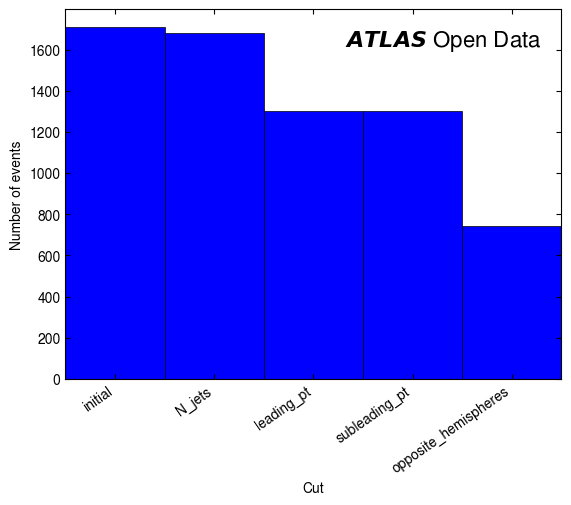

In [270]:
# Plot a cutflow bar chart
xlabels = [scope for scope in cutflow["event"]]
cuts = [cutflow["event"][scope] for scope in xlabels]
cutflow_fig, cutflow_ax = plt.subplots()
cutflow_ax.bar(xlabels,cuts,width=1.,linewidth=.5,edgecolor="k",color="blue")
cutflow_ax.set_xticks(xlabels); cutflow_ax.set_xticklabels(xlabels, rotation=35, ha="right")
inner_ticks(cutflow_ax)
cutflow_ax.margins(x=0)
cutflow_ax.set_ylabel("Number of events"); _ = cutflow_ax.set_xlabel("Cut")
atlas_label(cutflow_ax)

Plot $A_J=\frac{E_\mathrm{T1}-E_\mathrm{T2}}{E_\mathrm{T1}+E_\mathrm{T2}}$

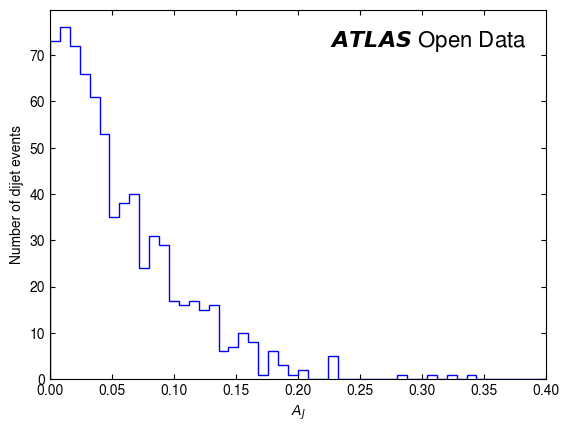

In [271]:
plt.close(cutflow_fig)
# Calculate and plot A_J values for all events
A_J = (jets["et"][:,0]-jets["et"][:,1])/(jets["et"][:,0]+jets["eta"][:,1])
AJ_fig, AJ_ax = plt.subplots()
AJ_ax.hist(A_J,range=(0,.4),bins=50,histtype="step",color="blue"); AJ_ax.set_xlim(0,.4)
_ = AJ_ax.set_xlabel(r"$A_J$"); _ = AJ_ax.set_ylabel(r"Number of dijet events")
inner_ticks(AJ_ax); atlas_label(AJ_ax)

FCalEtA
FCalEtC
eventNumber


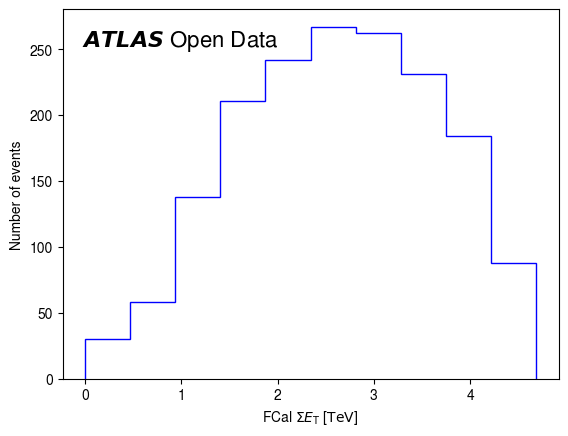

In [272]:
for field in fcal.fields: print(field)

fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
fcal_fig, fcal_ax = plt.subplots()
fcal_ax.hist(ak.flatten(fcal["TotalEt"]*1e-6,axis=None),histtype="step",color="blue")
fcal_ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]"); fcal_ax.set_ylabel("Number of events")
atlas_label(fcal_ax,loc="upper left")